# Proyek Analisis Data: E-commerce Public Dataset
- **Nama:** Zefanya Maureen Nathania
- **Email:** CDCC293D6X1530@student.devacademy.id
- **ID Dicoding:** CDCC293D6X1530

## Menentukan Pertanyaan Bisnis

Berikut adalah pertanyaan bisnis yang akan dijawab melalui proses analisis data:

1. **Tren Penjualan & Revenue:** Bagaimana tren performa penjualan (jumlah order) dan revenue per bulan dalam periode 2017-2018?
2. **Performa Produk:** Kategori produk apa yang paling banyak dan paling sedikit terjual?
3. **Demografi Geografis:** Bagaimana distribusi pelanggan berdasarkan negara bagian (state) di Brazil?
4. **Segmentasi Pelanggan:** Bagaimana segmentasi pelanggan berdasarkan RFM Analysis (Recency, Frequency, Monetary)?

## Import Semua Packages/Library yang Digunakan

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

## Data Wrangling

### Gathering Data

In [3]:
# Memuat semua dataset yang diperlukan
orders_df            = pd.read_csv('orders_dataset.csv')
order_items_df       = pd.read_csv('order_items_dataset.csv')
products_df          = pd.read_csv('products_dataset.csv')
product_category_df  = pd.read_csv('product_category_name_translation.csv')
order_payments_df    = pd.read_csv('order_payments_dataset.csv')
customers_df         = pd.read_csv('customers_dataset.csv')
geolocation_df       = pd.read_csv('geolocation_dataset.csv')

print('Semua dataset berhasil dimuat!')
print(f'\nRingkasan jumlah baris tiap dataset:')
datasets_info = {
    'orders'          : orders_df,
    'order_items'     : order_items_df,
    'products'        : products_df,
    'order_payments'  : order_payments_df,
    'customers'       : customers_df,
    'geolocation'     : geolocation_df
}
for name, df in datasets_info.items():
    print(f'  {name:<20}: {df.shape[0]:>8,} baris | {df.shape[1]} kolom')

Semua dataset berhasil dimuat!

Ringkasan jumlah baris tiap dataset:
  orders              :   99,441 baris | 8 kolom
  order_items         :  112,650 baris | 7 kolom
  products            :   32,951 baris | 9 kolom
  order_payments      :  103,886 baris | 5 kolom
  customers           :   99,441 baris | 5 kolom
  geolocation         : 1,000,163 baris | 5 kolom


**Insight Gathering Data:**
- Dataset terdiri dari 6 tabel utama yang saling berhubungan melalui kunci `order_id`, `customer_id`, dan `product_id`
- Tabel `orders` adalah pusat yang menghubungkan pelanggan dengan produk
- `customers` mencakup informasi lokasi pelanggan (kota dan negara bagian) yang penting untuk analisis demografi
- `geolocation` menyediakan koordinat lat/lng untuk visualisasi peta

### Assessing Data

In [4]:
# Memeriksa kualitas data pada setiap dataframe utama
main_datasets = {
    'orders'        : orders_df,
    'order_items'   : order_items_df,
    'order_payments': order_payments_df,
    'customers'     : customers_df,
    'products'      : products_df
}

for name, df in main_datasets.items():
    print(f'{'='*55}')
    print(f'Dataset  : {name}')
    print(f'Shape    : {df.shape[0]:,} baris x {df.shape[1]} kolom')
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f'Missing Values:')
        for col, cnt in missing.items():
            print(f'  - {col}: {cnt:,} ({cnt/len(df)*100:.1f}%)')
    else:
        print('Missing Values: Tidak ada')
    print(f'Duplikasi: {df.duplicated().sum():,} baris')
print(f'{'='*55}')

Dataset  : orders
Shape    : 99,441 baris x 8 kolom
Missing Values:
  - order_approved_at: 160 (0.2%)
  - order_delivered_carrier_date: 1,783 (1.8%)
  - order_delivered_customer_date: 2,965 (3.0%)
Duplikasi: 0 baris
Dataset  : order_items
Shape    : 112,650 baris x 7 kolom
Missing Values: Tidak ada
Duplikasi: 0 baris
Dataset  : order_payments
Shape    : 103,886 baris x 5 kolom
Missing Values: Tidak ada
Duplikasi: 0 baris
Dataset  : customers
Shape    : 99,441 baris x 5 kolom
Missing Values: Tidak ada
Duplikasi: 0 baris
Dataset  : products
Shape    : 32,951 baris x 9 kolom
Missing Values:
  - product_category_name: 610 (1.9%)
  - product_name_lenght: 610 (1.9%)
  - product_description_lenght: 610 (1.9%)
  - product_photos_qty: 610 (1.9%)
  - product_weight_g: 2 (0.0%)
  - product_length_cm: 2 (0.0%)
  - product_height_cm: 2 (0.0%)
  - product_width_cm: 2 (0.0%)
Duplikasi: 0 baris


**Insight Assessing Data:**
- `orders` memiliki missing values pada kolom tanggal pengiriman, yang terjadi karena pesanan yang belum/tidak terkirim
- Kolom-kolom tanggal masih bertipe string (`object`) dan perlu dikonversi ke format `datetime`
- `products` memiliki beberapa missing values pada kolom deskripsi produk (bukan kolom kritis untuk analisis ini)
- Tidak ditemukan duplikasi data pada dataset utama

### Cleaning Data

In [ ]:
# Konversi kolom tanggal ke format datetime
datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols:
    if col in orders_df.columns:
        orders_df[col] = pd.to_datetime(orders_df[col])

# Filter hanya pesanan yang sudah terkirim
orders_df = orders_df[orders_df['order_status'] == 'delivered'].copy()

# Hapus baris tanpa tanggal pengiriman
before = len(orders_df)
orders_df.dropna(subset=['order_delivered_customer_date'], inplace=True)
orders_df.reset_index(drop=True, inplace=True)
after = len(orders_df)

print(f'Data setelah cleaning: {after:,} baris pesanan terkirim')
print(f'Baris dihapus (tanpa tgl kirim): {before - after:,}')
print(f'Rentang waktu: {orders_df["order_purchase_timestamp"].min().date()} hingga {orders_df["order_purchase_timestamp"].max().date()}')

Data setelah cleaning: 96,470 baris pesanan terkirim
Baris dihapus (tanpa tgl kirim): 8
Rentang waktu: 2016-09-15 hingga 2018-08-29


**Insight Cleaning Data:**
- Setelah filtering, data yang tersisa hanya mencakup pesanan dengan status `delivered` dan memiliki tanggal pengiriman lengkap
- Data mencakup rentang transaksi dari akhir 2016 hingga pertengahan 2018
- Data sudah bersih dan siap untuk tahap analisis eksploratif (EDA) dan visualisasi

## Exploratory Data Analysis (EDA)

### Explore Data

In [ ]:
# Gabungkan order_items dengan produk dan terjemahan kategori
product_analysis_df = (
    order_items_df
    .merge(products_df, on='product_id', how='left')
    .merge(product_category_df, on='product_category_name', how='left')
)

# Mengelompokkan produk ke dalam kategori harga dengan Teknik Clustering (Binning)
price_bins   = [0, 50, 200, 500, 15000]
price_labels = ['Budget (< R$50)', 'Mid-Range (R$50-200)', 'Premium (R$200-500)', 'Luxury (> R$500)']

product_analysis_df['price_category'] = pd.cut(
    product_analysis_df['price'],
    bins=price_bins,
    labels=price_labels
)

print('--- Distribusi Produk Berdasarkan Kategori Harga (Binning) ---')
price_dist = product_analysis_df['price_category'].value_counts(sort=False)
for cat, cnt in price_dist.items():
    pct = cnt / len(product_analysis_df) * 100
    print(f'  {str(cat):<28}: {cnt:>7,} item ({pct:5.1f}%)')

print(f'\n--- Statistik Harga Produk ---')
stats = product_analysis_df['price'].describe()
for stat, val in stats.items():
    print(f'  {stat:<10}: R$ {val:>10,.2f}')

--- Distribusi Produk Berdasarkan Kategori Harga (Binning) ---
  Budget (< R$50)             :  39,317 item ( 34.9%)
  Mid-Range (R$50-200)        :  59,959 item ( 53.2%)
  Premium (R$200-500)         :  10,158 item (  9.0%)
  Luxury (> R$500)            :   3,216 item (  2.9%)

--- Statistik Harga Produk ---
  count     : R$ 112,650.00
  mean      : R$     120.65
  std       : R$     183.63
  min       : R$       0.85
  25%       : R$      39.90
  50%       : R$      74.99
  75%       : R$     134.90
  max       : R$   6,735.00


**Insight EDA:**
- Teknik **binning** ini berguna untuk segmentasi produk tanpa menggunakan algoritma machine learning
- Mayoritas produk berada di kategori **Budget** (harga < R$50) dan **Mid-Range** (R$50-200), mencerminkan pasar e-commerce yang price-sensitive
- Kategori **Luxury** (> R$500) merupakan segmen kecil dari sisi volume, namun berpotensi menghasilkan revenue yang signifikan
- Harga produk bervariasi sangat jauh (dari beberapa reais [R$] hingga ribuan reais [R$]), menunjukkan keragaman katalog yang tinggi

## Visualization & Explanatory Analysis

### **Pertanyaan 1:** 
#### Bagaimana tren performa penjualan (jumlah order) dan revenue per bulan dalam periode 2017-2018?

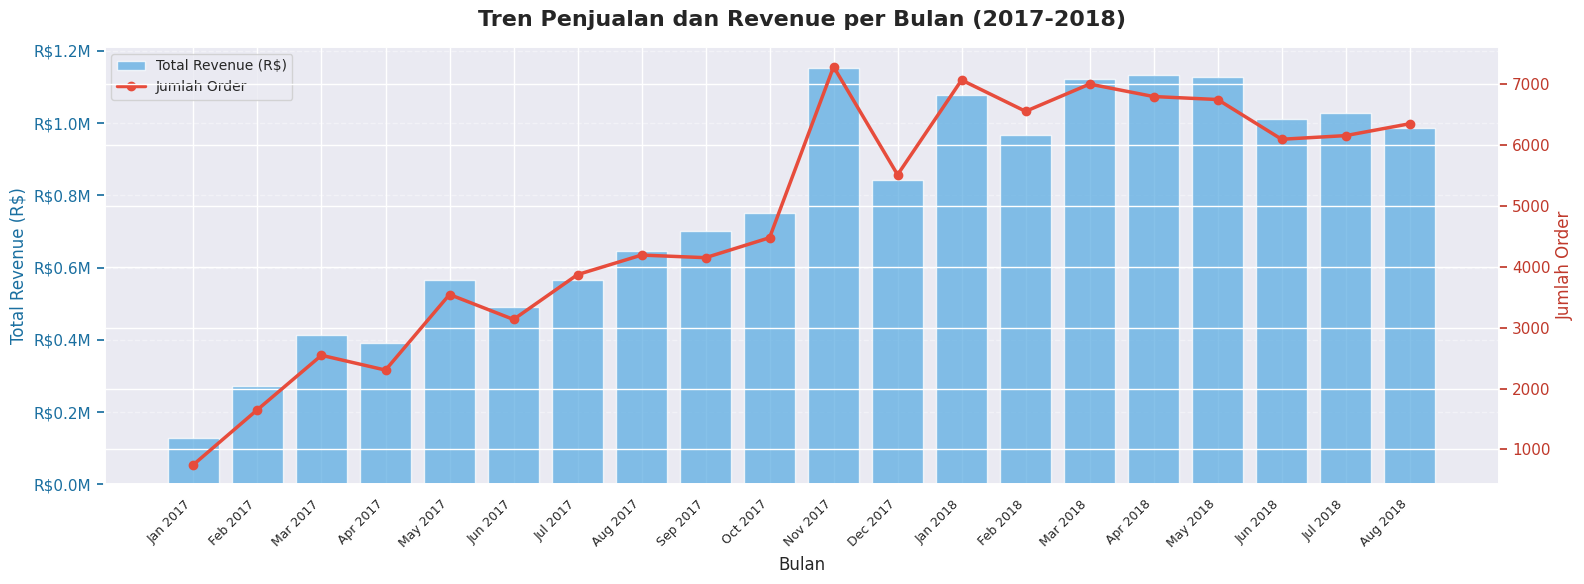

In [8]:
# Gabungkan orders dengan payments untuk mendapatkan data revenue
order_revenue_df = orders_df.merge(order_payments_df, on='order_id')

# Hitung statistik bulanan
monthly_stats = (
    order_revenue_df
    .resample(rule='ME', on='order_purchase_timestamp')
    .agg(
        order_count=('order_id', 'nunique'),
        total_revenue=('payment_value', 'sum')
    )
    .reset_index()
)
monthly_stats['order_month'] = monthly_stats['order_purchase_timestamp'].dt.strftime('%b %Y')

# Filter mulai Januari 2017 (sesuai pertanyaan bisnis)
monthly_stats = monthly_stats[
    monthly_stats['order_purchase_timestamp'] >= '2017-01-01'
].copy()

# Visualisasi Dual-Axis: Bar (Revenue) + Line (Order Count)
fig, ax1 = plt.subplots(figsize=(16, 6))
ax2 = ax1.twinx()

x_pos = range(len(monthly_stats))

ax1.bar(x_pos, monthly_stats['total_revenue'],
        color='#5DADE2', alpha=0.75, label='Total Revenue (R$)', zorder=2)
ax2.plot(x_pos, monthly_stats['order_count'],
         color='#E74C3C', marker='o', linewidth=2.5,
         markersize=6, label='Jumlah Order', zorder=3)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(monthly_stats['order_month'], rotation=45, ha='right', fontsize=9)
ax1.set_xlabel('Bulan', fontsize=12)
ax1.set_ylabel('Total Revenue (R$)', fontsize=12, color='#1A6FA0')
ax2.set_ylabel('Jumlah Order', fontsize=12, color='#C0392B')
ax1.tick_params(axis='y', colors='#1A6FA0')
ax2.tick_params(axis='y', colors='#C0392B')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, p: f'R${x/1e6:.1f}M')
)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

ax1.grid(axis='y', linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
plt.title('Tren Penjualan dan Revenue per Bulan (2017-2018)',
          fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [9]:
# Ringkasan insight numerik
idx_max_rev = monthly_stats['total_revenue'].idxmax()
idx_max_ord = monthly_stats['order_count'].idxmax()
print(f'Bulan Revenue Tertinggi : {monthly_stats.loc[idx_max_rev, "order_month"]}  (R$ {monthly_stats.loc[idx_max_rev, "total_revenue"]:,.0f})')
print(f'Bulan Order Terbanyak   : {monthly_stats.loc[idx_max_ord, "order_month"]}  ({monthly_stats.loc[idx_max_ord, "order_count"]:,} order)')

Bulan Revenue Tertinggi : Nov 2017  (R$ 1,153,393)
Bulan Order Terbanyak   : Nov 2017  (7,288 order)


**Insight Pertanyaan 1:**
- Tren penjualan menunjukkan **pertumbuhan yang konsisten dan signifikan** sepanjang 2017 hingga awal 2018
- Terdapat **lonjakan tajam pada November 2017**, kemungkinan besar dipicu oleh event promosi besar seperti *Black Friday*; ini menjadi puncak penjualan tertinggi dalam dataset
- **Revenue dan jumlah order bergerak searah** (berkorelasi positif), mengindikasikan nilai transaksi rata-rata yang relatif stabil
- Sepanjang pertengahan 2018, angka penjualan stabil di level tinggi, menandakan bisnis yang kian matang dan basis pelanggan yang sudah bertumbuh

### **Pertanyaan 2:** 
#### Kategori produk apa yang paling banyak dan paling sedikit terjual?

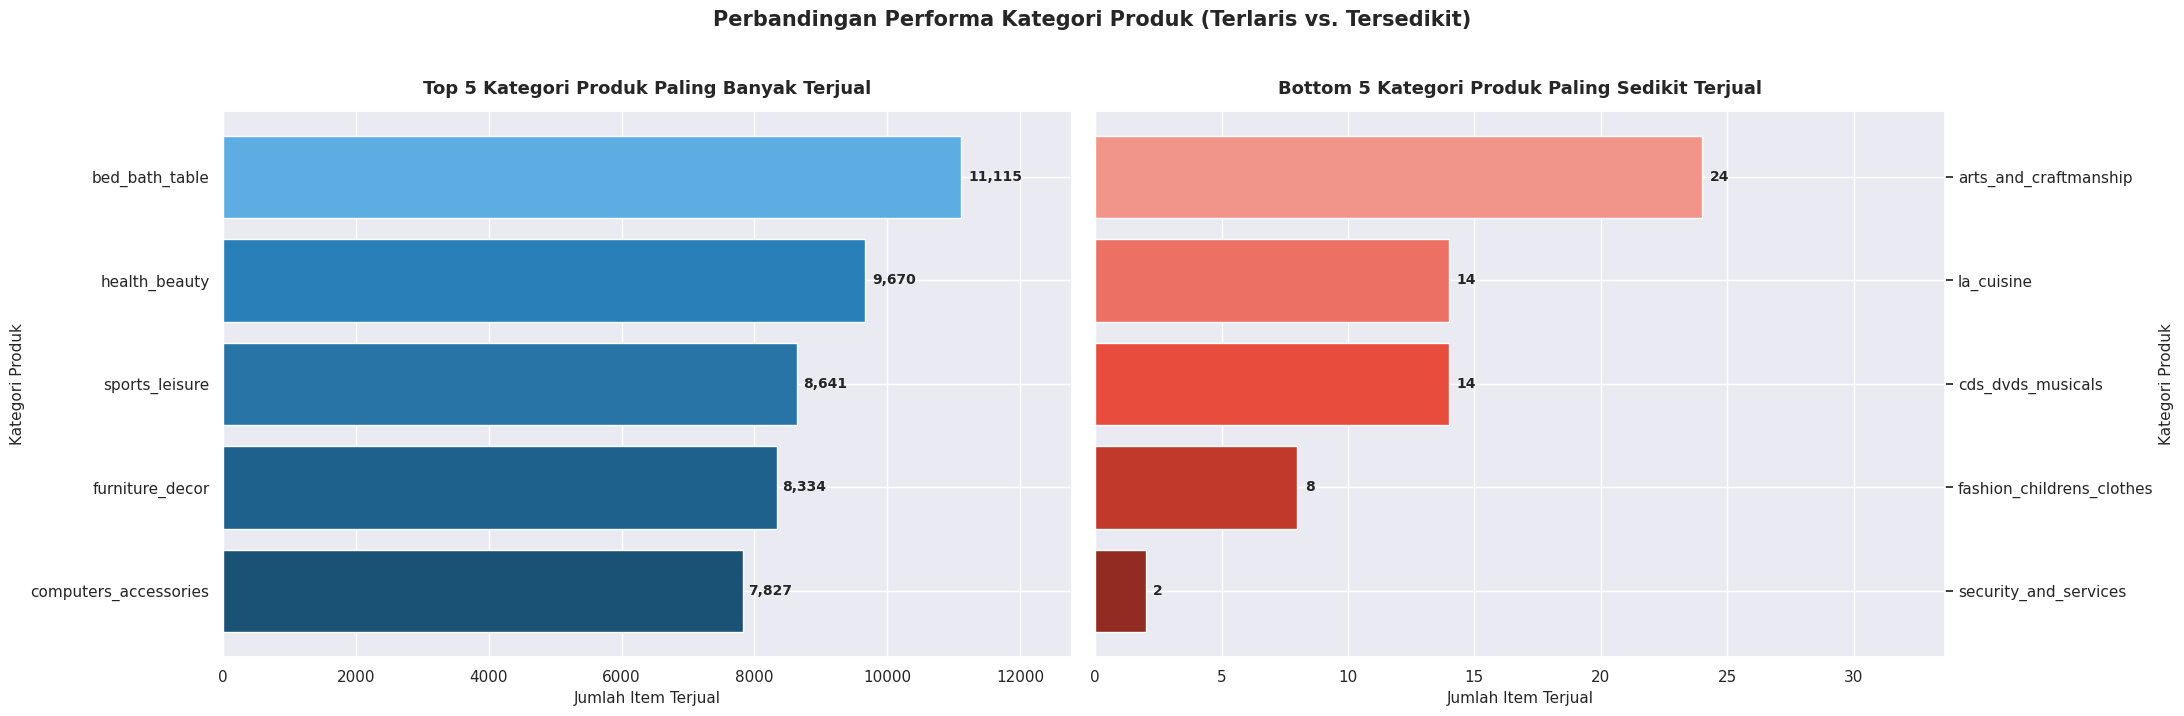

Total kategori produk: 71
Kategori Terlaris  : bed_bath_table (11,115 item)
Kategori Tersedikit: security_and_services (2 item)


In [10]:
# Gabungkan order_items dengan data produk dan terjemahan kategori
product_counts_df = (
    order_items_df
    .merge(products_df, on='product_id', how='left')
    .merge(product_category_df, on='product_category_name', how='left')
)

# Hitung total item terjual per kategori
category_sales = (
    product_counts_df
    .dropna(subset=['product_category_name_english'])
    .groupby('product_category_name_english')
    .agg(total_sold=('order_id', 'count'))
    .sort_values('total_sold', ascending=False)
    .reset_index()
)

top5 = category_sales.head(5).copy()
bot5 = category_sales.tail(5).copy()

# Visualisasi Side-by-Side Horizontal Bar Chart
fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Top 5 Terlaris
colors_top = ['#1A5276', '#1F618D', '#2874A6', '#2980B9', '#5DADE2']
bars_top = axes[0].barh(
    top5['product_category_name_english'][::-1],
    top5['total_sold'][::-1],
    color=colors_top, edgecolor='white'
)
axes[0].set_title('Top 5 Kategori Produk Paling Banyak Terjual',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Jumlah Item Terjual', fontsize=11)
axes[0].set_ylabel('Kategori Produk', fontsize=11)
for bar, val in zip(bars_top, top5['total_sold'][::-1]):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, top5['total_sold'].max() * 1.15)

# Bottom 5 Tersedikit
colors_bot = ['#922B21', '#C0392B', '#E74C3C', '#EC7063', '#F1948A']
bars_bot = axes[1].barh(
    bot5['product_category_name_english'][::-1],
    bot5['total_sold'][::-1],
    color=colors_bot, edgecolor='white'
)
axes[1].set_title('Bottom 5 Kategori Produk Paling Sedikit Terjual',
                  fontsize=13, fontweight='bold', pad=12)
axes[1].set_xlabel('Jumlah Item Terjual', fontsize=11)
axes[1].set_ylabel('Kategori Produk', fontsize=11)
axes[1].yaxis.set_label_position('right')
axes[1].yaxis.tick_right()
for bar, val in zip(bars_bot, bot5['total_sold'][::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlim(0, bot5['total_sold'].max() * 1.4)

plt.suptitle('Perbandingan Performa Kategori Produk (Terlaris vs. Tersedikit)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Total kategori produk: {len(category_sales)}')
print(f'Kategori Terlaris  : {top5.iloc[0]["product_category_name_english"]} ({top5.iloc[0]["total_sold"]:,} item)')
print(f'Kategori Tersedikit: {bot5.iloc[-1]["product_category_name_english"]} ({bot5.iloc[-1]["total_sold"]:,} item)')

**Insight Pertanyaan 2:**
- Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** adalah tiga kategori terlaris, mencerminkan kebutuhan sehari-hari pelanggan belanja online
- Dominasi kategori kebutuhan rumah tangga dan kesehatan menunjukkan karakteristik belanja online masyarakat Brazil
- Kategori dengan penjualan terendah adalah produk niche dan spesifik seperti **security_and_services** serta **fashion_childrens_clothes**
- **Rekomendasi:** untuk bisnis yaitu lebih difokuskan untuk meningkatkan stok dan promosi pada kategori terlaris, lalu evaluasi apakah kategori tersedikit layak dipertahankan atau perlu strategi khusus

### **Pertanyaan 3:** 
#### Bagaimana distribusi pelanggan berdasarkan negara bagian (state) di Brazil?

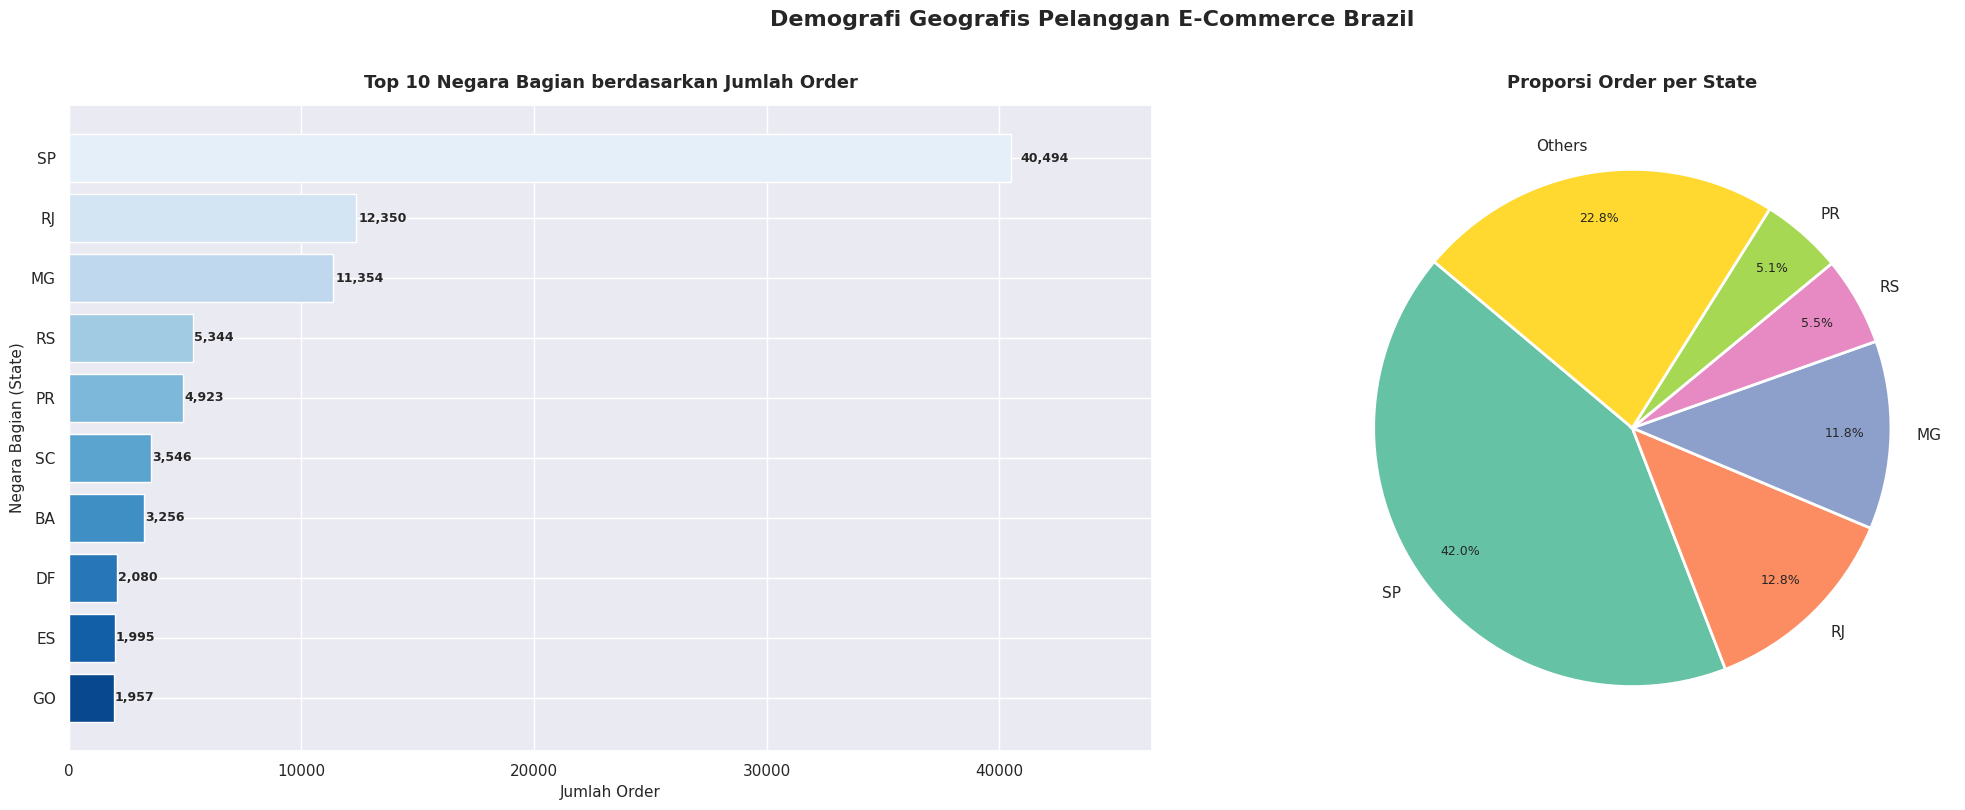

Negara bagian teratas: SP
  - Total Order          : 40,494
  - Pelanggan Unik       : 39,149
  - Share 3 state teratas: 66.5% dari total order


In [ ]:
# Gabungkan orders dengan customers untuk mendapatkan data geografis
orders_customers_df = orders_df.merge(customers_df, on='customer_id', how='left')

# Hitung jumlah order dan pelanggan unik per negara bagian
geo_stats = (
    orders_customers_df
    .groupby('customer_state')
    .agg(
        total_orders=('order_id', 'count'),
        unique_customers=('customer_unique_id', 'nunique')
    )
    .sort_values('total_orders', ascending=False)
    .reset_index()
)

top10_states = geo_stats.head(10).copy()

# Visualisasi: Bar Chart + Pie Chart
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Horizontal Bar Chart Top 10 States
bar_colors = sns.color_palette('Blues_r', n_colors=10)
bars = axes[0].barh(
    top10_states['customer_state'][::-1],
    top10_states['total_orders'][::-1],
    color=bar_colors, edgecolor='white'
)
axes[0].set_title('Top 10 Negara Bagian berdasarkan Jumlah Order',
                  fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Jumlah Order', fontsize=11)
axes[0].set_ylabel('Negara Bagian (State)', fontsize=11)
for bar, val in zip(bars, top10_states['total_orders'][::-1]):
    axes[0].text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2,
                 f'{val:,}', va='center', fontsize=9, fontweight='bold')
axes[0].set_xlim(0, top10_states['total_orders'].max() * 1.15)

# Pie Chart Proposisi Top 5 + Others
top5_states  = geo_stats.head(5)
others_count = geo_stats.iloc[5:]['total_orders'].sum()
pie_values   = list(top5_states['total_orders']) + [others_count]
pie_labels   = list(top5_states['customer_state']) + ['Others']
pie_colors   = sns.color_palette('Set2', n_colors=6)

wedges, texts, autotexts = axes[1].pie(
    pie_values, labels=pie_labels, autopct='%1.1f%%',
    colors=pie_colors, startangle=140, pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[1].set_title('Proporsi Order per State',
                  fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Demografi Geografis Pelanggan E-Commerce Brazil',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Negara bagian teratas: {geo_stats.iloc[0]["customer_state"]}')
print(f'  - Total Order          : {geo_stats.iloc[0]["total_orders"]:,}')
print(f'  - Pelanggan Unik       : {geo_stats.iloc[0]["unique_customers"]:,}')
total = geo_stats['total_orders'].sum()
top3_pct = geo_stats.head(3)['total_orders'].sum() / total * 100
print(f'  - Share 3 state teratas: {top3_pct:.1f}% dari total order')

**Insight Pertanyaan 3:**
- **Sao Paulo (SP)** mendominasi distribusi belanja online dengan nilai sebesar 40,494 (42,9%), sangat jauh daripada negara bagian lain, yang mencerminkan konsentrasi ekonomi digital di kota Sao Paulo Brazil
- **Rio de Janeiro (RJ)** dan **Minas Gerais (MG)** berada di posisi 2 dan 3, sejalan  dengan status kota metropolitan
- Ketiga state teratas (SP, RJ, MG) menyumbang sekitar **66% total order** yang menunjukkan ketimpangan geografis antar state di Brazil
- **Rekomendasi:** Optimalkan infrastruktur logistik dan warehouse di wilayah SP sebagai hub distribusi utama

### **Pertanyaan 4:** 
#### Bagaimana segmentasi pelanggan berdasarkan RFM Analysis?

--- Statistik RFM ---
        recency  frequency  monetary
count  93350.00   93350.00  93350.00
mean     237.95       1.08    165.20
std      152.59       0.45    226.32
min        1.00       1.00      0.00
25%      114.00       1.00     63.05
50%      219.00       1.00    107.78
75%      346.00       1.00    182.55
max      714.00      33.00  13664.08

Total pelanggan unik: 93,350


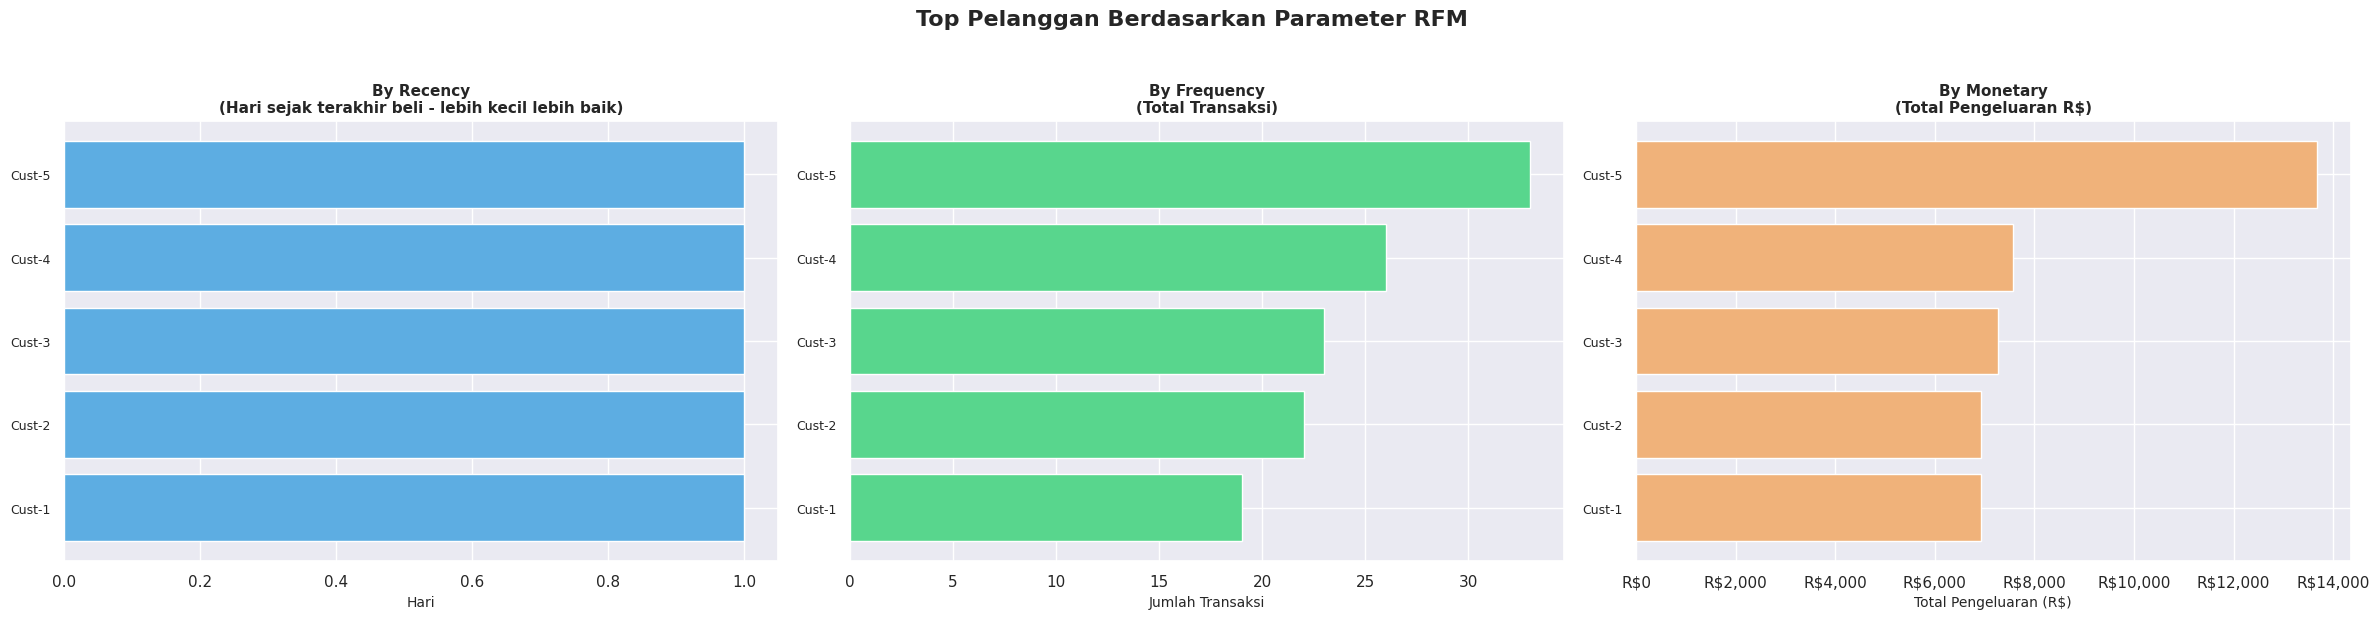

Max Frequency  : 33 transaksi
Max Monetary   : R$ 13,664.08
Min Recency    : 1 hari


In [14]:
# Gabungkan orders, payments, dan customers
rfm_base_df = (
    orders_df
    .merge(order_payments_df, on='order_id', how='left')
    .merge(customers_df, on='customer_id', how='left')
)

# Tanggal snapshot: 1 hari setelah transaksi terakhir
snapshot_date = rfm_base_df['order_purchase_timestamp'].max() + dt.timedelta(days=1)

# Hitung RFM menggunakan customer_unique_id
# (satu pelanggan nyata dapat memiliki beberapa customer_id di list)
rfm_summary = (
    rfm_base_df
    .groupby('customer_unique_id')
    .agg(
        recency  = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
        frequency= ('order_id', 'count'),
        monetary = ('payment_value', 'sum')
    )
    .reset_index()
    .rename(columns={'customer_unique_id': 'customer_id'})
)

print('--- Statistik RFM ---')
print(rfm_summary[['recency', 'frequency', 'monetary']].describe().round(2))
print(f'\nTotal pelanggan unik: {len(rfm_summary):,}')

# Visualisasi Top 5 Pelanggan per Parameter
fig, axes = plt.subplots(1, 3, figsize=(24, 6))

top_recency  = rfm_summary.nsmallest(5, 'recency')
top_freq     = rfm_summary.nlargest(5, 'frequency')
top_monetary = rfm_summary.nlargest(5, 'monetary')

# Recency (lebih kecil = lebih baru = lebih baik)
axes[0].barh(range(5), top_recency['recency'][::-1].values, color='#5DADE2')
axes[0].set_yticks(range(5))
axes[0].set_yticklabels(
    [f'Cust-{i+1}' for i in range(5)], fontsize=9
)
axes[0].set_title('By Recency\n(Hari sejak terakhir beli - lebih kecil lebih baik)',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Hari', fontsize=10)

# Frequency
axes[1].barh(range(5), top_freq['frequency'][::-1].values, color='#58D68D')
axes[1].set_yticks(range(5))
axes[1].set_yticklabels(
    [f'Cust-{i+1}' for i in range(5)], fontsize=9
)
axes[1].set_title('By Frequency\n(Total Transaksi)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Jumlah Transaksi', fontsize=10)

# Monetary
axes[2].barh(range(5), top_monetary['monetary'][::-1].values, color='#F0B27A')
axes[2].set_yticks(range(5))
axes[2].set_yticklabels(
    [f'Cust-{i+1}' for i in range(5)], fontsize=9
)
axes[2].set_title('By Monetary\n(Total Pengeluaran R$)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Total Pengeluaran (R$)', fontsize=10)
axes[2].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'R${x:,.0f}'))

plt.suptitle('Top Pelanggan Berdasarkan Parameter RFM',
             fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'Max Frequency  : {rfm_summary["frequency"].max()} transaksi')
print(f'Max Monetary   : R$ {rfm_summary["monetary"].max():,.2f}')
print(f'Min Recency    : {rfm_summary["recency"].min()} hari')

**Insight RFM (Top Customers):**
- Pelanggan dengan **Recency terendah** adalah pembeli yang paling baru bertransaksi, sehingga penting untuk dijaga loyalitasnya melalui program engagement dan penawaran yang relevan.
- Pelanggan dengan **Frequency tinggi** berbelanja jauh lebih sering dibanding rata-rata (mean **1.08**, max **33**) sehingga menjadi kandidat utama untuk program loyalitas atau membership premium.
- Pelanggan dengan **Monetary tinggi** memberikan kontribusi revenue paling besar (mean **165.20**, max **13,664.08**) sehingga layak diprioritaskan dengan layanan eksklusif dan promosi personal.
- Data menunjukkan sebagian besar pelanggan hanya melakukan **1 transaksi** (Q1 = median = Q3 = **1**), yang menunjukkan tantangan besar dalam customer retention dan perlunya strategi untuk mendorong pembelian ulang.

In [15]:
# === RFM SCORING (skala 1-5) ===

# Recency: lebih kecil (lebih baru) = lebih baik -> skor 5 untuk recency terkecil
rfm_summary['r_score'] = pd.qcut(
    rfm_summary['recency'], q=5,
    labels=[5, 4, 3, 2, 1], duplicates='drop'
)

# Frequency: lebih besar = lebih baik -> skor 5 untuk frequency terbesar
max_freq = rfm_summary['frequency'].max()
freq_bins = [0, 1, 2, 3, 5, max_freq + 1]
rfm_summary['f_score'] = pd.cut(
    rfm_summary['frequency'],
    bins=freq_bins, labels=[1, 2, 3, 4, 5]
)

# Monetary: lebih besar = lebih baik -> skor 5 untuk monetary terbesar
rfm_summary['m_score'] = pd.qcut(
    rfm_summary['monetary'], q=5,
    labels=[1, 2, 3, 4, 5], duplicates='drop'
)

# Konversi ke float dan hitung total RFM score
rfm_summary['r_score'] = rfm_summary['r_score'].astype(float)
rfm_summary['f_score'] = rfm_summary['f_score'].astype(float)
rfm_summary['m_score'] = rfm_summary['m_score'].astype(float)

rfm_summary.dropna(subset=['r_score', 'f_score', 'm_score'], inplace=True)
rfm_summary['rfm_score'] = (
    rfm_summary['r_score'] +
    rfm_summary['f_score'] +
    rfm_summary['m_score']
)

# SEGMENTASI PELANGGAN berdasarkan RFM Score
def segment_customer(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal Customers'
    elif score >= 7:
        return 'Potential Loyalists'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost / Inactive'

rfm_summary['segment'] = rfm_summary['rfm_score'].apply(segment_customer)

# Statistik per segmen
segment_stats = (
    rfm_summary.groupby('segment')
    .agg(
        jumlah_pelanggan=('customer_id', 'count'),
        avg_recency      =('recency', 'mean'),
        avg_frequency    =('frequency', 'mean'),
        avg_monetary     =('monetary', 'mean')
    )
    .round(1)
    .sort_values('jumlah_pelanggan', ascending=False)
)
print('=== Statistik Segmen Pelanggan ===')
print(segment_stats.to_string())

=== Statistik Segmen Pelanggan ===
                     jumlah_pelanggan  avg_recency  avg_frequency  avg_monetary
segment                                                                        
Potential Loyalists             44287        195.4            1.1         188.5
At Risk                         25460        306.5            1.0          83.7
Loyal Customers                 12418         84.7            1.2         347.0
Lost / Inactive                 11047        424.6            1.0          50.5
Champions                         138         76.8            4.7         536.8


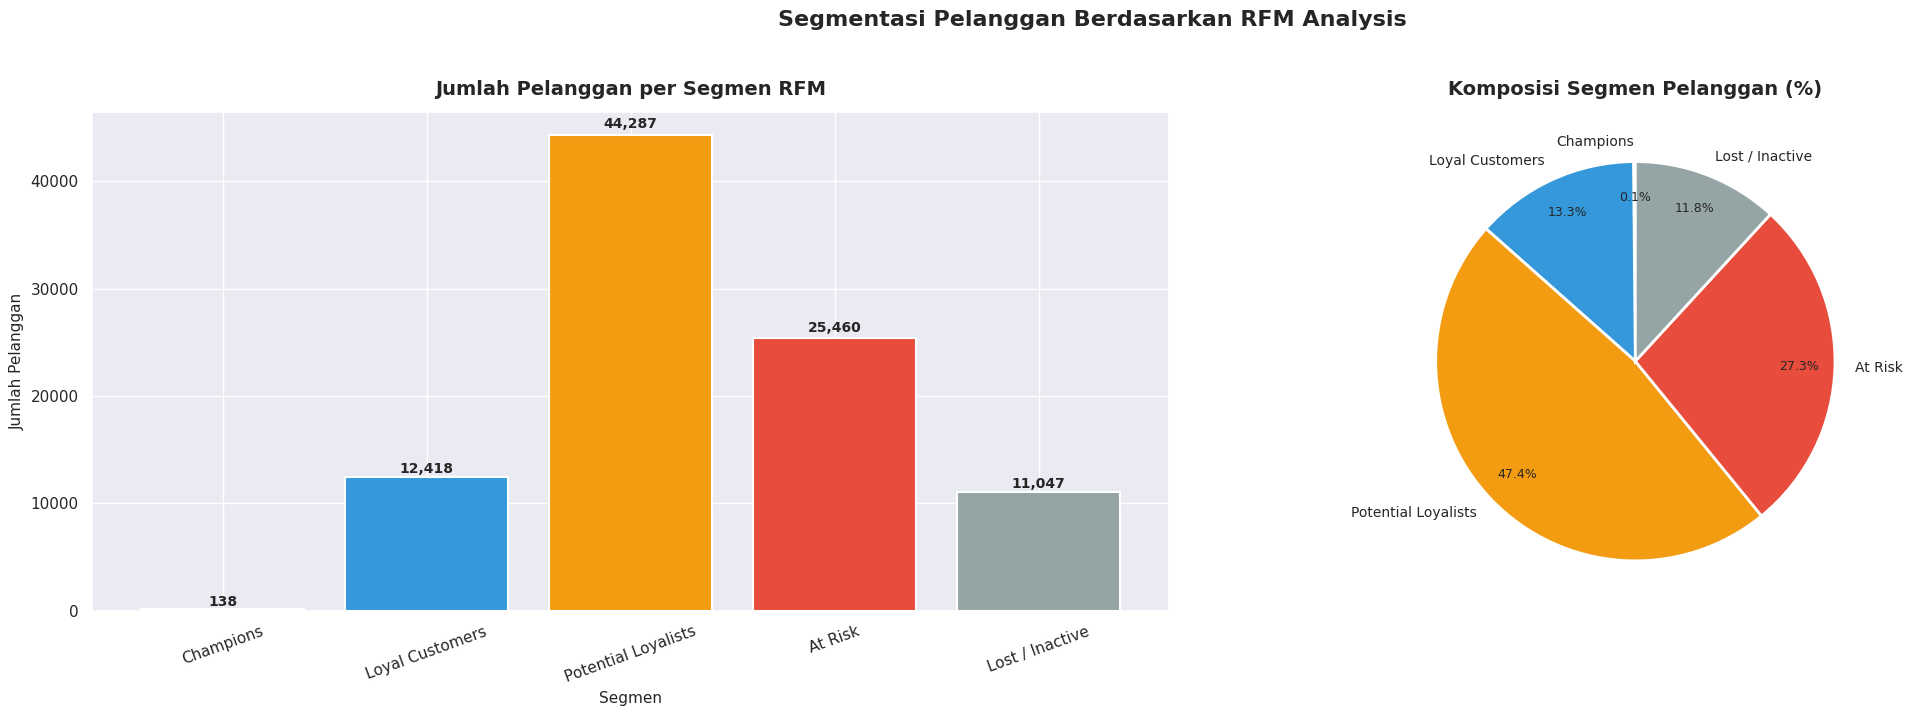

In [16]:
# Visualisasi Segmentasi RFM
segment_order = ['Champions', 'Loyal Customers', 'Potential Loyalists', 'At Risk', 'Lost / Inactive']
seg_color_map = {
    'Champions'          : '#1ABC9C',
    'Loyal Customers'    : '#3498DB',
    'Potential Loyalists': '#F39C12',
    'At Risk'            : '#E74C3C',
    'Lost / Inactive'    : '#95A5A6'
}

seg_count = rfm_summary['segment'].value_counts().reset_index()
seg_count.columns = ['segment', 'count']
seg_count['segment'] = pd.Categorical(
    seg_count['segment'], categories=segment_order, ordered=True
)
seg_count = seg_count.sort_values('segment')
bar_colors_seg = [seg_color_map[s] for s in seg_count['segment']]

fig, axes = plt.subplots(1, 2, figsize=(22, 7))

# Bar Chart jumlah pelanggan per segmen
bars = axes[0].bar(
    seg_count['segment'], seg_count['count'],
    color=bar_colors_seg, edgecolor='white', linewidth=1.5
)
axes[0].set_title('Jumlah Pelanggan per Segmen RFM',
                  fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Segmen', fontsize=11)
axes[0].set_ylabel('Jumlah Pelanggan', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, seg_count['count']):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01,
                 f'{val:,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold')

# Pie Chart komposisi segmen
wedges, texts, autotexts = axes[1].pie(
    seg_count['count'],
    labels=seg_count['segment'],
    autopct='%1.1f%%',
    colors=bar_colors_seg,
    startangle=90,
    pctdistance=0.82,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)
axes[1].set_title('Komposisi Segmen Pelanggan (%)',
                  fontsize=14, fontweight='bold', pad=12)

plt.suptitle('Segmentasi Pelanggan Berdasarkan RFM Analysis',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Insight Segmentasi RFM:**
- *Calon Pelanggan loyal (47.4%)* cukup besar sehingga perusahaan perlu fokus pada peningkatan frekuensi belanja untuk mengubah mereka menjadi pelanggan loyal.
- *Risiko Churn (39.1%)*, gabungan segmen At Risk dan Lost cukup besar sehingga diperlukan strategi agar pelanggan tidak benar-benar pergi.
- *Kelangkaan pelanggan Champions (0.1%)* sehingga perlu strategi eskalasi dari segmen Loyal Customers.
- *Rekomendasi Aksi:*
    - Champions: Berikan apresiasi dan perlakuan VIP.
    - Loyal & Potential: Dorong pembelian berulang dengan promo personal atau membership.
    - At Risk & Lost: Kirim kampanye win-back (diskon besar) atau survei untuk reaktivasi.

## Analisis Lanjutan: Geospatial Analysis

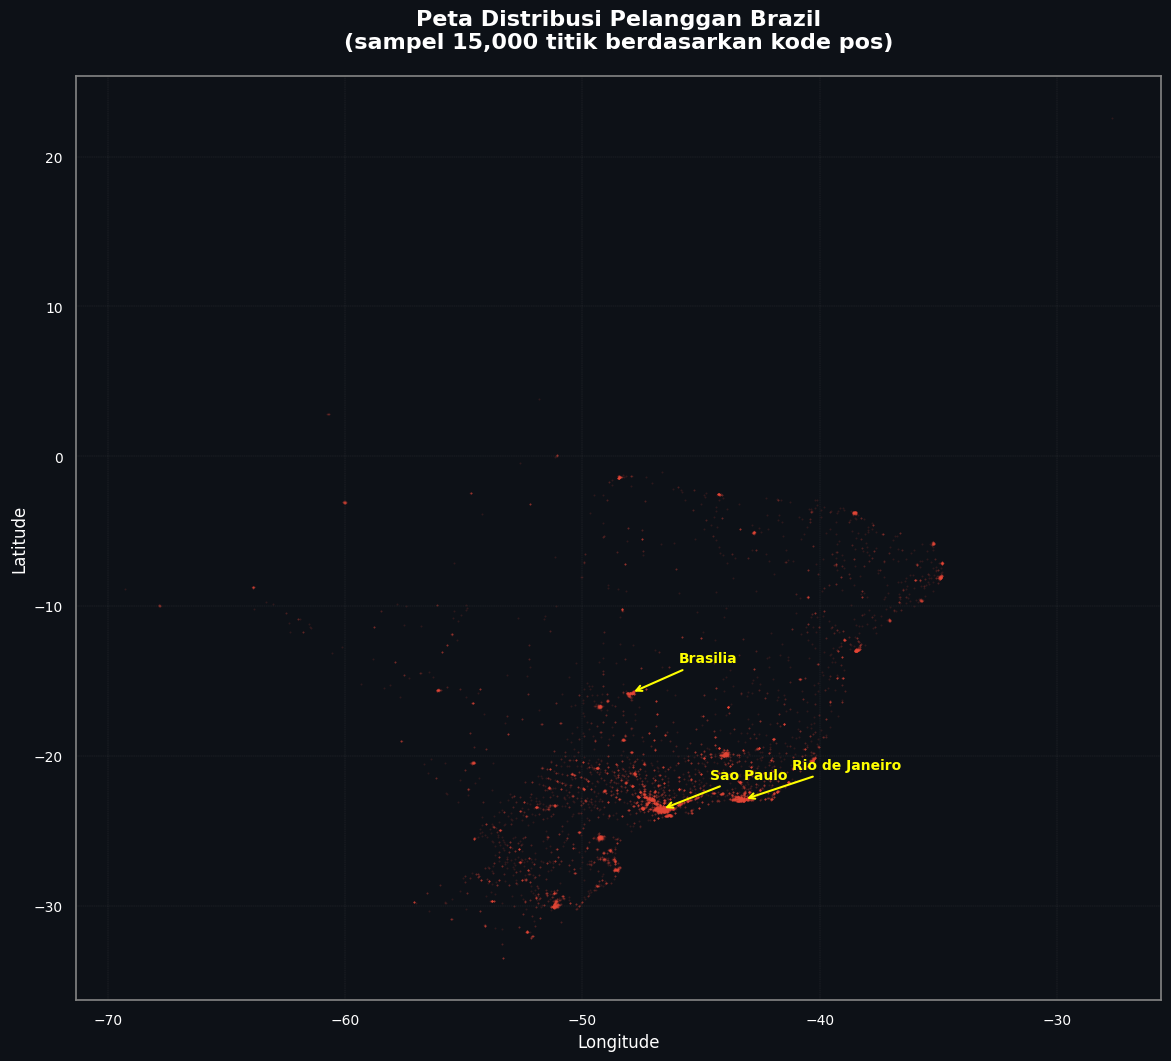

In [19]:
import matplotlib.pyplot as plt

# Visualisasi Geospatial (Hanya Peta, Ukuran Diperbesar)
fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor('#0d1117') # Menyamakan warna background luar dengan peta

# Scatter Plot: Peta Distribusi Pelanggan
ax.set_facecolor('#0d1117')
ax.scatter(
    geo_sample['lng'], geo_sample['lat'],
    c='#E74C3C', alpha=0.15, s=2, linewidths=0
)

ax.set_title(
    f'Peta Distribusi Pelanggan Brazil\n(sampel {n_sample:,} titik berdasarkan kode pos)',
    fontsize=16, fontweight='bold', color='white', pad=20
)
ax.set_xlabel('Longitude', fontsize=12, color='white')
ax.set_ylabel('Latitude', fontsize=12, color='white')
ax.tick_params(colors='white', labelsize=10)
ax.grid(color='gray', linestyle='--', linewidth=0.3, alpha=0.3)

for spine in ax.spines.values():
    spine.set_edgecolor('gray')

# Anotasi kota besar
key_cities = {
    'Sao Paulo': (-46.63, -23.55),
    'Rio de Janeiro': (-43.18, -22.91),
    'Brasilia': (-47.93, -15.78)
}

for city, (lng_c, lat_c) in key_cities.items():
    ax.annotate(
        city, xy=(lng_c, lat_c),
        color='yellow', fontsize=10, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='yellow', lw=1.5),
        xytext=(lng_c + 2, lat_c + 2)
    )

plt.show()

**Insight Geospatial Analysis:**
- Visualisasi peta memperlihatkan **titik-titik merah terkonsentrasi di wilayah pesisir tenggara Brazil**, khususnya area metropolitan Sao Paulo, Rio de Janeiro, dan Belo Horizonte
- Pola distribusi ini konsisten dengan data ekonomi Brazil di wilayah **tenggara adalah pusat perekonomian** negara
- Wilayah **Sul (Selatan)** seperti Parana (PR), Rio Grande do Sul (RS), dan Santa Catarina (SC) menunjukkan pertumbuhan e-commerce yang aktif dan dapat menjadi target ekspansi berikutnya
- **Kawasan utara (Amazon region)** hampir tidak memiliki pelanggan, alasannya karena keterbatasan infrastruktur internet dan akses logistik e-commerce
- Analisis ini menggunakan data koordinat nyata dari `geolocation` yang dikaitkan langsung dengan `customers` melalui kode pos

## Conclusion

Setelah dilakukan analisis eksplorasi dan visualisasi di atas,dapat diambil kesimpulan bahwa

### 1. Tren Penjualan & Revenue *(Pertanyaan 1)*
Bisnis menunjukkan **pertumbuhan yang konsisten dan signifikan** dari Januari 2017 hingga pertengahan 2018. Puncak penjualan terjadi pada **November 2017**, yang terjadi karena adanya event promosi besar seperti *Black Friday*. Revenue dan jumlah order bergerak searah (korelasi positif), menandakan nilai rata-rata transaksi yang stabil. Tren ini mengindikasikan bisnis yang sehat dan sedang dalam fase pertumbuhan.

### 2. Performa Kategori Produk *(Pertanyaan 2)*
Kategori **bed_bath_table**, **health_beauty**, dan **sports_leisure** mendominasi penjualan. Sebaliknya, kategori niche seperti **security_and_services** dan **fashion_childrens_clothes** memiliki volume sangat rendah. Perusahaan belanja online perlu untuk *fokus pada investasi stok dan promosi pada kategori terlaris*, serta evaluasi kelayakan ekonomi kategori yang underperforming.

### 3. Demografi Geografis Pelanggan *(Pertanyaan 3)*
Pelanggan sangat terkonsentrasi di wilayah tenggara Brazil, terutama **São Paulo (SP)**, **Rio de Janeiro (RJ)**, dan **Minas Gerais (MG)**, dimana ketiganya menyumbang sebesar 66% dari total order. . Perusahaan belanja online perlu untuk *mengoptimalkan infrastruktur di SP sebagai hub utama* dan memperluas jangkauan logistik ke wilayah yang potensial seperti wilayah Sul (Selatan) dan wilayah Barat.

### 4. Segmentasi Pelanggan RFM *(Pertanyaan 4)*
Analisis RFM menunjukkan bahwa segmen terbesar adalah **calon pelanggan loyal (47.4%)**, sehingga perusahaan perlu fokus mendorong peningkatan frekuensi belanja agar mereka naik menjadi pelanggan loyal. Di sisi lain, **risiko churn (39.1%)** dari segmen **At Risk** dan **Lost** juga cukup tinggi, sehingga diperlukan strategi retensi dan reaktivasi. Sementara itu, pelanggan **Champions** masih sangat sedikit (0.1%), sehingga perlu strategi untuk mendorong pelanggan loyal naik ke segmen ini.

**Rekomendasi aksi:**
- **Champions:** berikan apresiasi dan perlakuan VIP.
- **Loyal & Potential:** dorong pembelian berulang melalui promo personal atau membership.
- **At Risk & Lost:** lakukan kampanye *win-back* seperti diskon besar atau survei reaktivasi.

### 5. Analisis Geospasial *(Tambahan)*
Analisis geospasial menunjukkan bahwa pelanggan terkonsentrasi di **wilayah tenggara Brazil**, terutama di sekitar **Sao Paulo, Rio de Janeiro, dan Belo Horizonte**, yang memang merupakan pusat ekonomi utama negara. Wilayah **selatan** seperti **Parana, Rio Grande do Sul, dan Santa Catarina** juga terlihat memiliki aktivitas e-commerce yang cukup kuat dan berpotensi menjadi area ekspansi berikutnya. Sebaliknya, **wilayah utara** masih memiliki jumlah pelanggan yang sangat rendah, kemungkinan dipengaruhi oleh keterbatasan infrastruktur internet dan logistik. Secara keseluruhan, persebaran pelanggan mencerminkan bahwa aktivitas e-commerce sangat dipengaruhi oleh kekuatan ekonomi dan ketersediaan infrastruktur di setiap wilayah.